In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base_dir = r"starstxt4"

rows = []   # will hold dicts to build the table

for star in sorted(os.listdir(base_dir)):
    star_dir = os.path.join(base_dir, star)
    if not os.path.isdir(star_dir):
        continue

    txt_path = os.path.join(star_dir, f"{star}_vsini.txt")
    if not os.path.isfile(txt_path):
        continue

    vs1_list, e1_list = [], []
    vs2_list, e2_list = [], []

    with open(txt_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # strip “[ … ],”
            line = line.strip("[],")
            parts = [p.strip() for p in line.split(",")]

            # primary
            v1 = float(parts[1])
            e1 = float(parts[2])
            vs1_list.append(v1)
            e1_list.append(e1)

            # secondary (optional)
            if len(parts) > 4:
                v2s, e2s = parts[3], parts[4]
                if v2s.lower() != "nan" and e2s.lower() != "nan":
                    vs2_list.append(float(v2s))
                    e2_list.append(float(e2s))

    
    mean_v1 = np.nanmean(vs1_list)
    err_v1  = np.nanmax(e1_list) if len(e1_list) else np.nan

    if len(vs2_list):
        mean_v2 = np.nanmean(vs2_list)
        err_v2  = np.nanmax(e2_list)
    else:
        mean_v2, err_v2 = np.nan, np.nan

    rows.append({
        "Star": star,
        "Vsini_1": mean_v1,
        "Err_1": err_v1,
        "Vsini_2": mean_v2,
        "Err_2": err_v2
    })



#table build
tbl = pd.DataFrame(rows)

print(tbl.to_string(index=False, col_space=10, float_format="%.3f"))

prim_vsini = tbl["Vsini_1"].values
sec_vsini  = tbl["Vsini_2"].dropna().values


                     Star    Vsini_1      Err_1    Vsini_2      Err_2
                    29Dra      8.136      0.049        NaN        NaN
   2MASSJ08171221+0736164     15.165      0.089        NaN        NaN
   2MASSJ08504952+1217158     25.131      0.188     21.184      0.277
   2MASSJ17270871+2700144      4.115      0.091        NaN        NaN
                    54Cam     12.889      0.055     16.533      0.098
       ASASJ073642+0354.3      8.371      0.058        NaN        NaN
       ASASJ155307+2028.6     16.044      0.174        NaN        NaN
       ASASJ162510+0514.9     40.135      0.246        NaN        NaN
       ASASJ210323+1930.9     17.674      0.304        NaN        NaN
                BD+142519     36.832      0.199        NaN        NaN
                BD+201895     24.357      0.161        NaN        NaN
                    BMCVn     14.889      0.098        NaN        NaN
          BPSCS22950-0027     12.349      0.090        NaN        NaN
                    

In [2]:
import os
import numpy as np
import pandas as pd

base_dir = r"starstxt4"

rows_K = []   # semi-amplitude table

K1_val, K2_val = [], []
K1_upper, K2_upper, K1_lower, K2_lower = [],[],[],[]

for star in sorted(os.listdir(base_dir)):
    star_dir = os.path.join(base_dir, star)
    if not os.path.isdir(star_dir):
        continue

    rv_path = os.path.join(star_dir, f"{star}_RVs.txt")
    if not os.path.isfile(rv_path):
        continue

    rv1_list, rv1_up_list, rv1_low_list = [], [], []
    rv2_list, rv2_up_list, rv2_low_list = [], [], []

    with open(rv_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            line = line.strip("[],")
            parts = [p.strip() for p in line.split(",")]

            # primary
            rv1      = float(parts[1])
            rv1_up   = float(parts[2])
            rv1_low  = float(parts[3])

            rv1_list.append(rv1)
            rv1_up_list.append(rv1_up)
            rv1_low_list.append(rv1_low)

            # secondary (optional)
            if len(parts) >= 7:
                rv2_s, rv2_up_s, rv2_low_s = parts[4], parts[5], parts[6]

                if rv2_s.lower() != "nan":
                    rv2      = float(rv2_s)
                    rv2_up   = float(rv2_up_s)
                    rv2_low  = float(rv2_low_s)

                    rv2_list.append(rv2)
                    rv2_up_list.append(rv2_up)
                    rv2_low_list.append(rv2_low)


    rv1_arr = np.array(rv1_list, float)
    if len(rv1_arr) > 0:
        K1 = (np.nanmax(rv1_arr) - np.nanmin(rv1_arr)) / 2.0

        
        K1_up  = np.nanmax(rv1_up_list)
        K1_low = np.nanmax(rv1_low_list)

    else:
        K1, K1_up, K1_low = np.nan, np.nan, np.nan

    # secondary
    if len(rv2_list) > 0:
        rv2_arr = np.array(rv2_list, float)
        K2 = (np.nanmax(rv2_arr) - np.nanmin(rv2_arr)) / 2.0

        
        K2_up  = np.nanmax(rv2_up_list)
        K2_low = np.nanmax(rv2_low_list)

    else:
        K2, K2_up, K2_low = np.nan, np.nan, np.nan

    rows_K.append({
        "Star": star,
        "K1": K1,
        "K1_upper_err": K1_up,
        "K1_lower_err": K1_low,
        "K2": K2,
        "K2_upper_err": K2_up,
        "K2_lower_err": K2_low
    })

    K1_val.append(K1)
    K2_val.append(K2)
    K1_upper.append(K1_up)
    K2_upper.append(K2_up)
    K1_lower.append(K1_low)
    K2_lower.append(K2_low)


tbl_K = pd.DataFrame(rows_K)


print(tbl_K.to_string(index=False, col_space=10, float_format="%.3f"))


                     Star         K1  K1_upper_err  K1_lower_err         K2  K2_upper_err  K2_lower_err
                    29Dra      0.984         0.141         0.168        NaN           NaN           NaN
   2MASSJ08171221+0736164     12.752         0.193         0.153        NaN           NaN           NaN
   2MASSJ08504952+1217158     18.098         0.324         0.380      4.965         0.369         0.565
   2MASSJ17270871+2700144      3.492         0.051         0.045        NaN           NaN           NaN
                    54Cam     49.191         0.157         0.155     48.587         0.248         0.225
       ASASJ073642+0354.3      0.575         0.108         0.091        NaN           NaN           NaN
       ASASJ155307+2028.6     47.053         0.211         0.258        NaN           NaN           NaN
       ASASJ162510+0514.9     55.507         0.970         1.043        NaN           NaN           NaN
       ASASJ210323+1930.9     28.870         0.344         0.367

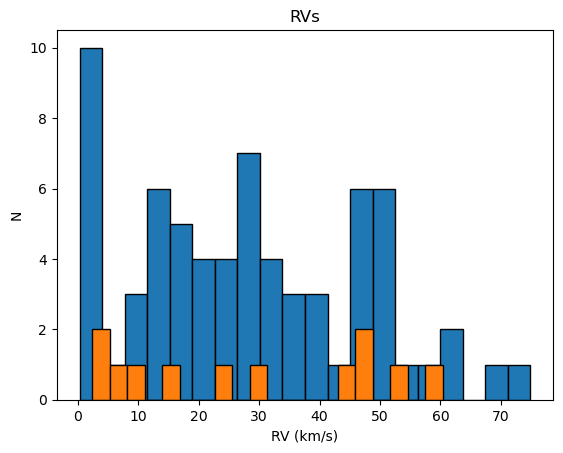

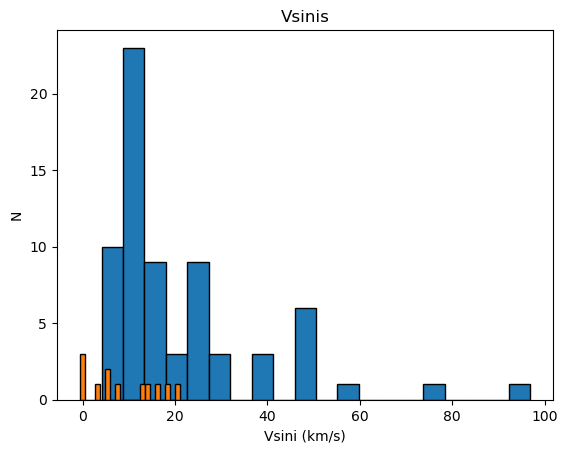

In [3]:
plt.hist(K1_val, bins = 20, edgecolor = 'k')
plt.hist(K2_val, bins = 20, edgecolor = 'k')
plt.title('RVs')
plt.xlabel('RV (km/s)')
plt.ylabel('N')
plt.show()



plt.hist(prim_vsini, bins = 20, edgecolor = 'k')
plt.hist(sec_vsini,  bins = 20, edgecolor = 'k')
plt.title('Vsinis')
plt.xlabel('Vsini (km/s)')
plt.ylabel('N')
plt.show()

In [4]:
len(prim_vsini)

69

In [5]:
#summary table

nan = np.nan
    #Star, N, RV1_amp, rv1_hi, rv1_lo, RV2_amp, rv2_hi, rv2_lo
fullsummary = np.array([
['29Dra', 5, 0.992, 0.151, 0.167, nan, nan, nan],
['2MASSJ08171221+0736164', 4, 12.751, 0.193, 0.153, nan, nan, nan],
['2MASSJ08504952+1217158', 4, 18.098, 0.324, 0.380, 4.965, 0.369, 0.565],
['2MASSJ17270871+2700144', 3, 3.493, 0.051, 0.045, nan, nan, nan],
['54Cam', 5, 49.191, 0.157, 0.155, 48.586, 0.248, 0.225],
['ASASJ073642+0354.3', 8, 0.576, 0.108, 0.091, nan, nan, nan],
['ASASJ155307+2028.6', 4, 47.053, 0.211, 0.258, nan, nan, nan],
['ASASJ162510+0514.9', 9, 55.507, 0.970, 1.043, nan, nan, nan],
['ASASJ210323+1930.9', 12, 28.870, 0.344, 0.367, nan, nan, nan],
['BD+142519', 7, 34.534, 0.264, 0.272, nan, nan, nan],
['BD+201895', 3, 1.123, 0.197, 0.210, nan, nan, nan],
['BMCVn', 7, 12.139, 0.136, 0.153, nan, nan, nan],
['BPSCS22950-0027', 12, 26.011, 0.153, 0.150, nan, nan, nan],
['CGTri', 12, 39.050, 0.654, 0.553, nan, nan, nan],
['EPCVn', 12, 49.956, 0.106, 0.117, nan, nan, nan],
['FMLyn', 6, 31.651, 0.287, 0.290, nan, nan, nan],
['FNCom', 13, 43.760, 0.303, 0.297, nan, nan, nan],
['FRBoo', 9, 3.316, 0.161, 0.156, nan, nan, nan],
['FVCnc', 4, 27.034, 0.077, 0.069, 28.581, 0.118, 0.126],
['GSC00563-00384', 10, 14.422, 0.107, 0.125, nan, nan, nan],
['GSC02769-00149', 11, 23.567, 0.323, 0.348, nan, nan, nan],
['HD113714', 5, 74.895, 0.248, 0.246, nan, nan, nan],
['HD161570', 6, 21.266, 0.061, 0.062, nan, nan, nan],
['HD347929', 13, 0.853, 0.132, 0.142, nan, nan, nan],
['HD53476', 4, 20.336, 0.152, 0.135, nan, nan, nan],
['HRPsc', 12, 21.484, 0.707, 0.667, nan, nan, nan],
['HUVir', 12, 46.728, 0.691, 0.683, nan, nan, nan],
['KLCnc', 5, 35.939, 0.845, 0.897, nan, nan, nan],
['KNCnc', 9, 27.324, 0.153, 0.160, 6.229, 0.319, 0.273],
['KYBoo', 10, 0.510, 0.184, 0.205, nan, nan, nan],
['MPBoo', 5, 0.276, 0.079, 0.079, nan, nan, nan],
['MSBoo', 5, 18.595, 0.140, 0.199, nan, nan, nan],
['MXBoo', 4, 0.262, 0.108, 0.111, nan, nan, nan],
['MXDra', 9, 39.695, 0.266, 0.305, nan, nan, nan],
['NPCom', 6, 61.883, 0.431, 0.413, nan, nan, nan],
['NRLib', 8, 50.539, 1.143, 1.246, nan, nan, nan],
['OOBoo', 4, 30.136, 0.137, 0.117, 22.988, 0.377, 0.340],
['QZBoo', 12, 32.924, 0.146, 0.190, nan, nan, nan],
['ROTSE1J135649.21+242927.1', 6, 23.842, 0.109, 0.092, 2.318, 0.113, 0.118],
['ROTSE1J160518.19+372623.5', 4, 46.531, 0.138, 0.132, 45.682, 0.348, 0.369],
['ROTSE1J162157.22+381733.6', 4, 27.572, 0.103, 0.099, nan, nan, nan],
['ROTSE1J170537.88+335052.5', 4, 20.952, 0.274, 0.282, 16.809, 1.050, 0.991],
['ROTSE1J172404.95+182937.3', 3, 18.915, 0.155, 0.160, nan, nan, nan],
['ROTSE1J183703.58+280017.1', 5, 12.077, 0.226, 0.246, nan, nan, nan],
['ROTSE1J184706.07+434032.7', 5, 7.540, 0.127, 0.137, nan, nan, nan],
['RXJ1112.4+3950', 15, 51.708, 0.774, 0.626, nan, nan, nan],
['TYC1339-572-1', 4, 12.046, 0.169, 0.178, 8.673, 0.131, 0.121],
['TYC1543-131-1', 3, 7.990, 0.086, 0.088, nan, nan, nan],
['TYC2268-394-1', 11, 58.238, 1.174, 1.262, nan, nan, nan],
['TYC2645-156-1', 6, 25.825, 0.236, 0.250, nan, nan, nan],
['TYC3401-730-1', 3, 62.355, 1.527, 1.685, nan, nan, nan],
['TYC3557-919-1', 10, 26.490, 0.129, 0.127, nan, nan, nan],
['TYC3927-1130-1', 5, 35.127, 0.386, 0.328, nan, nan, nan],
['TYC4216-800-1', 5, 15.280, 0.145, 0.116, nan, nan, nan],
['TYC4223-399-1', 23, 26.459, 1.976, 2.145, nan, nan, nan],
['TYC4415-328-1', 10, 12.916, 0.154, 0.212, nan, nan, nan],
['TYC4422-1970-1', 18, 38.306, 0.552, 0.511, nan, nan, nan],
['TYC4428-785-1', 3, 9.378, 0.106, 0.091, nan, nan, nan],
['TYC4667-90-1', 11, 52.485, 0.344, 0.450, nan, nan, nan],
['TYC5003-138-1', 8, 46.438, 0.246, 0.288, 60.411, 0.286, 0.297],
['TYC583-566-1', 11, 51.934, 0.516, 0.503, nan, nan, nan],
['UCAC228842571', 35, 45.614, 12.318, 18.544, 46.522, 7.848, 17.727],
['V424Gem', 4, 28.076, 0.091, 0.106, nan, nan, nan],
['V457Vir', 6, 47.867, 0.446, 0.405, nan, nan, nan],
['V498And', 11, 30.630, 0.280, 0.373, nan, nan, nan],
['V503Hya', 5, 70.636, 0.647, 0.578, 54.455, 0.904, 0.902],
['V832Her', 5, 10.286, 0.059, 0.058, nan, nan, nan],
['V834Her', 7, 1.159, 0.165, 0.194, nan, nan, nan],
['V846Her', 5, 17.532, 0.206, 0.262, nan, nan, nan]
])


In [6]:
len(fullsummary)

69

In [7]:
#check I had to make sure I've gotten all of the stars

summary_names = [row[0] for row in fullsummary]
table_names = tbl["Star"].tolist()


summary_set = set(summary_names)
table_set   = set(table_names)

missing_from_table = summary_set - table_set
extra_in_table     = table_set - summary_set

print("=== Stars in summary but missing from table ===")
for s in sorted(missing_from_table):
    print("  ", s)

print("\n=== Stars in table but NOT in summary ===")
for s in sorted(extra_in_table):
    print("  ", s)

=== Stars in summary but missing from table ===

=== Stars in table but NOT in summary ===
